# Análise exploratória dos dados telefônicos de Campinas

Este notebook faz uma análise exploratória simples da base `Campinas.parquet`.

O foco aqui é entender a estrutura dos dados, o comportamento dos emissores, o volume de chamadas, a diversidade de contatos, a distância residencial já presente no parquet e preparar uma tabela de arestas emissor-receptor. Nenhuma etapa usa o arquivo `residencias.csv`.

## Perguntas desta EDA

- Quantos emissores existem na base?
- As colunas do parquet estão consistentes?
- Como se distribuem o total de chamadas e a quantidade de receptores por emissor?
- Poucos emissores concentram muitas chamadas?
- Como transformar as listas internas em uma tabela simples de arestas emissor-receptor?
- As chamadas estão concentradas em poucos pares emissor-receptor?
- Como se distribuem as distâncias residenciais entre emissores e receptores?
- Existe alguma relação aparente entre distância residencial, quantidade de chamadas e duração?
- Os emissores tendem a falar com muitos contatos ou concentrar chamadas em poucos contatos?

## Imports e caminhos

In [3]:
from pathlib import Path
import sys
from config import CITY_NAME, CITY_PARQUET

# Evita extensões opcionais que podem causar conflito em alguns ambientes.
sys.modules['numexpr'] = None
sys.modules['bottleneck'] = None

import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 50)
pd.set_option('display.max_colwidth', 80)

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (9, 5)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

DATA_DIR = Path('./dados')
CITY_PATH = DATA_DIR / CITY_PARQUET
RESIDENCIAS_PATH = DATA_DIR / 'residencias.csv'

CITY_PATH.exists()

True

In [4]:
CITY_PATH

WindowsPath('dados/Lavras.parquet')

## Dicionário dos dados usados

| Coluna | Como será usada aqui |
|---|---|
| `id_emisor` | Identificador anonimizado do usuário emissor. |
| `total_calls_make` | Total de chamadas feitas pelo emissor. |
| `unique_receivers` | Quantidade de receptores distintos chamados pelo emissor. |
| `IDs_receivers_corr` | Lista de receptores associados ao emissor. |
| `q_calls_corr` | Lista com a quantidade de chamadas para cada receptor. |
| `residence_distance_km_corr` | Lista com a distância residencial, em km, entre emissor e receptor. |
| `calls_duration_total_corr` | Lista com a duração total das chamadas para cada receptor. |

## Carregamento da base

Antes de carregar tudo, olhamos rapidamente o schema do parquet. Depois lemos a base em memória, porque o arquivo de Campinas é pequeno para uma EDA local.

In [5]:
parquet_file = pq.ParquetFile(CITY_PATH)
print(parquet_file.schema)
print(f'Linhas: {parquet_file.metadata.num_rows:,}')
print(f'Grupos de linhas: {parquet_file.metadata.num_row_groups}')

required group field_id=-1 schema {
  optional binary field_id=-1 city_residences (String);
  optional binary field_id=-1 id_emisor (String);
  optional int64 field_id=-1 total_calls_make;
  optional int64 field_id=-1 unique_receivers;
  optional group field_id=-1 IDs_receivers_corr (List) {
    repeated group field_id=-1 list {
      optional binary field_id=-1 element (String);
    }
  }
  optional group field_id=-1 q_calls_corr (List) {
    repeated group field_id=-1 list {
      optional int64 field_id=-1 element;
    }
  }
  optional group field_id=-1 residence_distance_km_corr (List) {
    repeated group field_id=-1 list {
      optional double field_id=-1 element;
    }
  }
  optional group field_id=-1 calls_duration_total_corr (List) {
    repeated group field_id=-1 list {
      optional double field_id=-1 element;
    }
  }
}

Linhas: 2,968
Grupos de linhas: 1


In [6]:
df = parquet_file.read().to_pandas()
df.head()

,city_residences,id_emisor,total_calls_make,unique_receivers,IDs_receivers_corr,q_calls_corr,residence_distance_km_corr,calls_duration_total_corr
0,Lavras,6A25BB13E0EB57AF0BC1B12E09066090,3,1,[09733364070D428DB7DB059EB964AEEA],[3],[1.6244811412788938],[8.469999999999999]
1,Lavras,A1F433373241547B7E7D0E4E63A8574F,27,1,[EAFB8A6F8D9AD7E91529F6EF7F15BF2B],[27],[1.6244811412788938],[19.590000000000003]
2,Lavras,C0EE955E574B587D037F1DC493ADDEC4,1,1,[54AAE028CCC31C4B800CB1E7E9799253],[1],[3.0086606658789745],[1.43]
3,Lavras,66406B8907461FBB978468BE0D0E22F1,3,1,[033183C2EE18E03EFDF1083D53EE92B5],[3],[1.5927049003955993],[29.29]
4,Lavras,EB4EF78A3B0BAAD118885F2B93881B5F,22,2,"[3F895921B209C4161B721382802BD3BC, 3DB84B3C732D58C6DE17A63C3C5618C0]","[21, 1]","[0.0, 0.0]","[18.19, 0.97]"


## Qualidade e consistência

Esta etapa verifica se há nulos, quantos valores únicos existem por coluna e se as listas internas batem com os totais declarados. Isso é importante porque cada posição das listas representa o mesmo par emissor-receptor.

In [7]:
resumo_colunas = pd.DataFrame({
    'tipo': df.dtypes.astype(str),
    'nulos': df.isna().sum(),
    'pct_nulos': df.isna().mean(),
    'n_unicos': [df[col].astype(str).nunique() for col in df.columns],
})
resumo_colunas

,tipo,nulos,pct_nulos,n_unicos
city_residences,str,0,0.0,1
id_emisor,str,0,0.0,2968
total_calls_make,int64,0,0.0,234
unique_receivers,int64,0,0.0,36
IDs_receivers_corr,object,0,0.0,2911
q_calls_corr,object,0,0.0,1927
residence_distance_km_corr,object,0,0.0,1488
calls_duration_total_corr,object,0,0.0,2775


In [8]:
list_cols = ['IDs_receivers_corr', 'q_calls_corr', 'residence_distance_km_corr', 'calls_duration_total_corr']

for col in list_cols:
    df[f'n_{col}'] = df[col].apply(len)

df['soma_q_calls_corr'] = df['q_calls_corr'].apply(sum)

checks = pd.DataFrame({
    'linhas': [len(df)],
    'emissores_unicos': [df['id_emisor'].nunique()],
    'emissores_duplicados': [df['id_emisor'].duplicated().sum()],
    'unique_receivers_confere': [(df['unique_receivers'] == df['n_IDs_receivers_corr']).all()],
    'listas_mesmo_tamanho': [(df[[f'n_{c}' for c in list_cols]].nunique(axis=1) == 1).all()],
    'total_calls_confere': [(df['total_calls_make'] == df['soma_q_calls_corr']).all()],
})
checks

,linhas,emissores_unicos,emissores_duplicados,unique_receivers_confere,listas_mesmo_tamanho,total_calls_confere
0,2968,2968,0,True,True,True


In [9]:
inconsistencias = df.loc[
    (df['unique_receivers'] != df['n_IDs_receivers_corr']) |
    (df[[f'n_{c}' for c in list_cols]].nunique(axis=1) != 1) |
    (df['total_calls_make'] != df['soma_q_calls_corr']),
    ['id_emisor', 'total_calls_make', 'soma_q_calls_corr', 'unique_receivers'] + [f'n_{c}' for c in list_cols]
]

inconsistencias.head()

,id_emisor,total_calls_make,soma_q_calls_corr,unique_receivers,n_IDs_receivers_corr,n_q_calls_corr,n_residence_distance_km_corr,n_calls_duration_total_corr


## Visão geral dos emissores

Cada linha representa um emissor. Aqui criamos uma métrica simples, `chamadas_por_receptor`, que ajuda a diferenciar quem liga para muitos contatos de quem concentra chamadas em poucos contatos.

In [10]:
df['chamadas_por_receptor'] = df['total_calls_make'] / df['unique_receivers'].replace(0, np.nan)

resumo_geral = pd.DataFrame({
    'emissores': [df['id_emisor'].nunique()],
    'chamadas_total': [df['total_calls_make'].sum()],
    'receptores_distintos_somados': [df['unique_receivers'].sum()],
    'media_chamadas_por_emissor': [df['total_calls_make'].mean()],
    'mediana_chamadas_por_emissor': [df['total_calls_make'].median()],
    'media_receptores_por_emissor': [df['unique_receivers'].mean()],
    'mediana_receptores_por_emissor': [df['unique_receivers'].median()],
})
resumo_geral

,emissores,chamadas_total,receptores_distintos_somados,media_chamadas_por_emissor,mediana_chamadas_por_emissor,media_receptores_por_emissor,mediana_receptores_por_emissor
0,2968,116955,12432,39.405323,20.0,4.188679,3.0


In [11]:
emissor_cols = ['total_calls_make', 'unique_receivers', 'chamadas_por_receptor']
df[emissor_cols].describe(percentiles=[.01, .05, .25, .5, .75, .9, .95, .99]).T

,count,mean,std,min,1%,5%,25%,50%,75%,90%,95%,99%,max
total_calls_make,2968.0,39.405323,53.080334,1.0,1.0,1.0,6.000000,20.000000,51.000,101.000000,144.300,243.99,581.0
unique_receivers,2968.0,4.188679,4.032324,1.0,1.0,1.0,2.000000,3.000000,5.000,8.000000,11.000,20.00,40.0
chamadas_por_receptor,2968.0,10.777777,17.180989,1.0,1.0,1.0,2.160714,5.166667,11.875,25.383333,39.325,80.66,246.0


## Distribuições dos emissores

O primeiro gráfico mostra a distribuição original do total de chamadas. O segundo usa `log1p`, isto é, `log(1 + x)`, para enxergar melhor a cauda da distribuição quando há poucos usuários muito ativos.

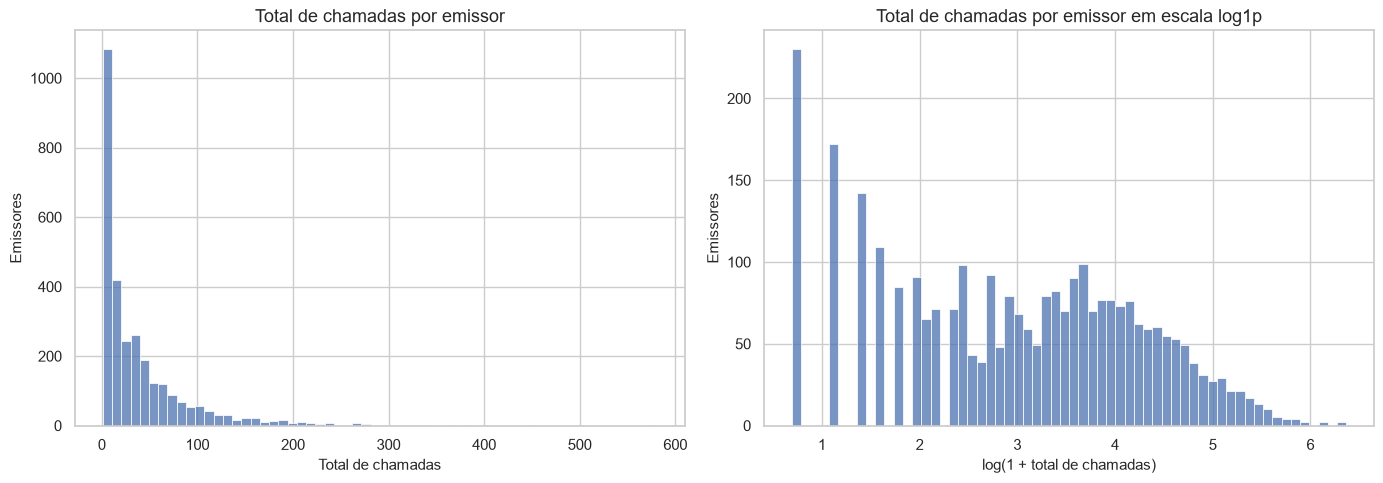

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data=df, x='total_calls_make', bins=60, ax=axes[0])
axes[0].set_title('Total de chamadas por emissor')
axes[0].set_xlabel('Total de chamadas')
axes[0].set_ylabel('Emissores')

sns.histplot(x=np.log1p(df['total_calls_make']), bins=60, ax=axes[1])
axes[1].set_title('Total de chamadas por emissor em escala log1p')
axes[1].set_xlabel('log(1 + total de chamadas)')
axes[1].set_ylabel('Emissores')

plt.tight_layout()
plt.show()

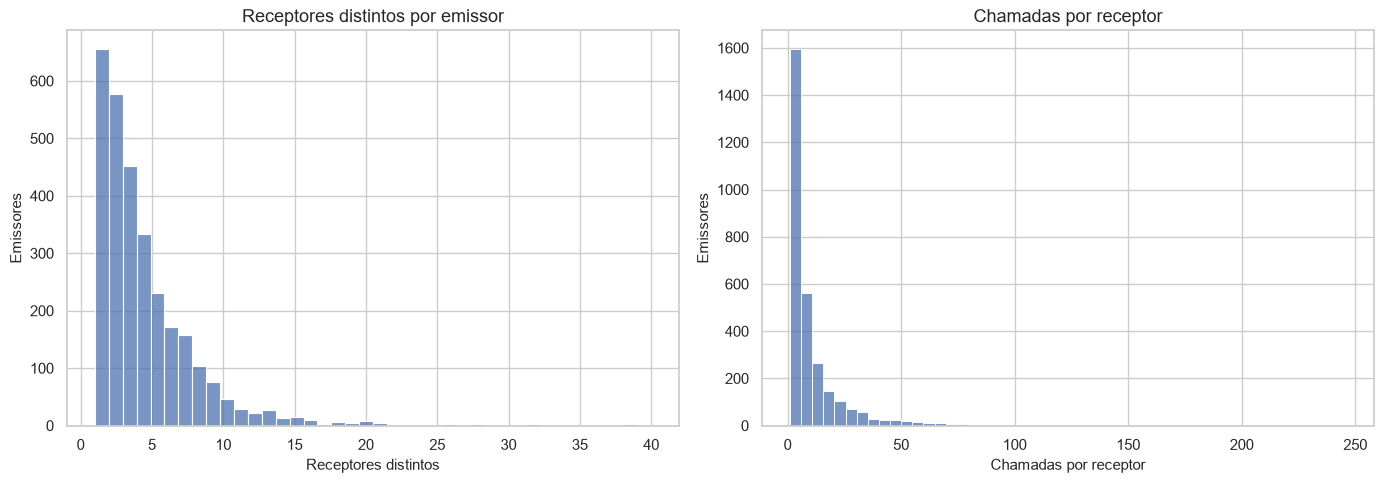

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data=df, x='unique_receivers', bins=40, ax=axes[0])
axes[0].set_title('Receptores distintos por emissor')
axes[0].set_xlabel('Receptores distintos')
axes[0].set_ylabel('Emissores')

sns.histplot(data=df, x='chamadas_por_receptor', bins=50, ax=axes[1])
axes[1].set_title('Chamadas por receptor')
axes[1].set_xlabel('Chamadas por receptor')
axes[1].set_ylabel('Emissores')

plt.tight_layout()
plt.show()

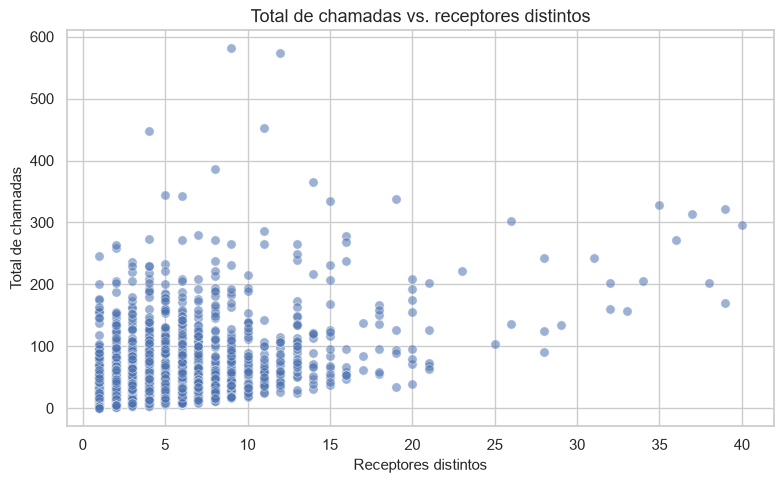

In [14]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df,
    x='unique_receivers',
    y='total_calls_make',
    alpha=0.55,
    s=45,
)
plt.title('Total de chamadas vs. receptores distintos')
plt.xlabel('Receptores distintos')
plt.ylabel('Total de chamadas')
plt.tight_layout()
plt.show()

## Emissores mais ativos

A tabela abaixo mostra os emissores com maior volume de chamadas. Ela ajuda a identificar se existem observações muito acima do restante da base.

In [15]:
top_emissores = df[[
    'id_emisor',
    'total_calls_make',
    'unique_receivers',
    'chamadas_por_receptor',
]].sort_values('total_calls_make', ascending=False)

top_emissores.head(15)

,id_emisor,total_calls_make,unique_receivers,chamadas_por_receptor
2579,645254314639EDACA0DFCD37DCF6A2DD,581,9,64.555556
1401,8DE7ECCB2BD455F7883092DD0567D43B,574,12,47.833333
767,1A1C2B664417B00DEF20104017E778BD,453,11,41.181818
1316,36FE36ED18B50C18B29D1A16275E64CF,447,4,111.750000
1252,47A1310E83C6871424E6106584B5724A,387,8,48.375000
2857,E70490E25BFF4AEA2C8E966E7F72D4BA,365,14,26.071429
742,A23B55E0005C0BB7BEE6FC96944140C1,345,5,69.000000
969,127BC2BA57366C0E58F1DC75427ED796,343,6,57.166667
2207,F0B60CA06AA2036C6B519470EFC25D2A,338,19,17.789474
298,E7AFDDF4A191642EB2733A355EAC57AB,334,15,22.266667


## Pareto do volume de chamadas

O Pareto mede concentração. Aqui a pergunta é: qual percentual das chamadas vem dos emissores mais ativos? Se poucos emissores explicam grande parte das chamadas, a curva sobe rapidamente.

In [16]:
pareto = df[['id_emisor', 'total_calls_make', 'unique_receivers']].sort_values('total_calls_make', ascending=False).reset_index(drop=True)
pareto['rank'] = np.arange(1, len(pareto) + 1)
pareto['pct_emissores'] = pareto['rank'] / len(pareto)
pareto['pct_chamadas_acum'] = pareto['total_calls_make'].cumsum() / pareto['total_calls_make'].sum()
pareto.head(10)

,id_emisor,total_calls_make,unique_receivers,rank,pct_emissores,pct_chamadas_acum
0,645254314639EDACA0DFCD37DCF6A2DD,581,9,1,0.000337,0.004968
1,8DE7ECCB2BD455F7883092DD0567D43B,574,12,2,0.000674,0.009876
2,1A1C2B664417B00DEF20104017E778BD,453,11,3,0.001011,0.013749
3,36FE36ED18B50C18B29D1A16275E64CF,447,4,4,0.001348,0.017571
4,47A1310E83C6871424E6106584B5724A,387,8,5,0.001685,0.020880
5,E70490E25BFF4AEA2C8E966E7F72D4BA,365,14,6,0.002022,0.024001
6,A23B55E0005C0BB7BEE6FC96944140C1,345,5,7,0.002358,0.026951
7,127BC2BA57366C0E58F1DC75427ED796,343,6,8,0.002695,0.029883
8,F0B60CA06AA2036C6B519470EFC25D2A,338,19,9,0.003032,0.032773
9,E7AFDDF4A191642EB2733A355EAC57AB,334,15,10,0.003369,0.035629


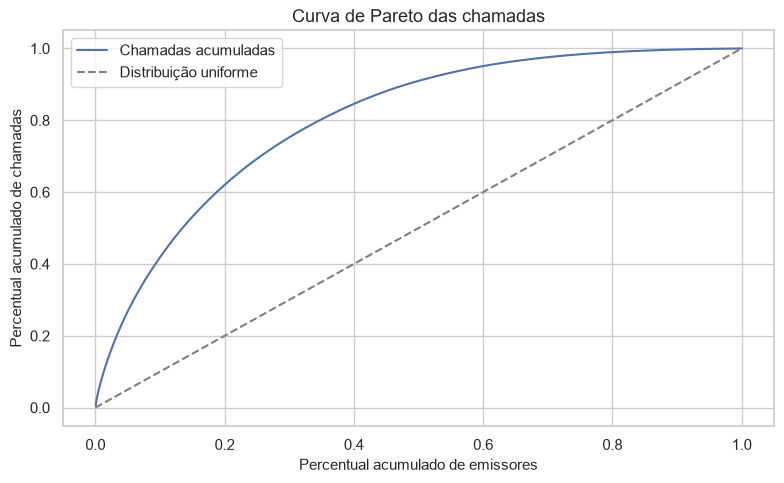

Top 1% dos emissores: 8.3% das chamadas
Top 5% dos emissores: 26.9% das chamadas
Top 10% dos emissores: 41.9% das chamadas
Top 20% dos emissores: 62.0% das chamadas


In [17]:
plt.figure(figsize=(8, 5))
plt.plot(pareto['pct_emissores'], pareto['pct_chamadas_acum'], label='Chamadas acumuladas')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Distribuição uniforme')
plt.title('Curva de Pareto das chamadas')
plt.xlabel('Percentual acumulado de emissores')
plt.ylabel('Percentual acumulado de chamadas')
plt.legend()
plt.tight_layout()
plt.show()

for corte in [0.01, 0.05, 0.10, 0.20]:
    n = max(1, int(np.ceil(corte * len(pareto))))
    pct = pareto.loc[:n-1, 'total_calls_make'].sum() / pareto['total_calls_make'].sum()
    print(f'Top {corte:.0%} dos emissores: {pct:.1%} das chamadas')

## Preparação da tabela de arestas emissor-receptor

O parquet guarda os receptores em listas. Para analisar pares emissor-receptor, expandimos essas listas para uma tabela em que cada linha é um par.

A tabela de arestas inclui quantidade de chamadas, duração total, duração média por chamada e distância residencial em km.

In [18]:
edges_records = []

for row in df.itertuples(index=False):
    for receiver, q_calls, distance_km, duration_total in zip(
        row.IDs_receivers_corr,
        row.q_calls_corr,
        row.residence_distance_km_corr,
        row.calls_duration_total_corr,
    ):
        edges_records.append({
            'id_emisor': row.id_emisor,
            'id_receiver': receiver,
            'q_calls': q_calls,
            'residence_distance_km': distance_km,
            'calls_duration_total': duration_total,
        })

edges = pd.DataFrame(edges_records)
edges['avg_duration_per_call'] = edges['calls_duration_total'] / edges['q_calls'].replace(0, np.nan)
edges.head()

,id_emisor,id_receiver,q_calls,residence_distance_km,calls_duration_total,avg_duration_per_call
0,6A25BB13E0EB57AF0BC1B12E09066090,09733364070D428DB7DB059EB964AEEA,3,1.624481,8.47,2.823333
1,A1F433373241547B7E7D0E4E63A8574F,EAFB8A6F8D9AD7E91529F6EF7F15BF2B,27,1.624481,19.59,0.725556
2,C0EE955E574B587D037F1DC493ADDEC4,54AAE028CCC31C4B800CB1E7E9799253,1,3.008661,1.43,1.430000
3,66406B8907461FBB978468BE0D0E22F1,033183C2EE18E03EFDF1083D53EE92B5,3,1.592705,29.29,9.763333
4,EB4EF78A3B0BAAD118885F2B93881B5F,3F895921B209C4161B721382802BD3BC,21,0.000000,18.19,0.866190


In [19]:
resumo_edges = pd.DataFrame({
    'arestas': [len(edges)],
    'emissores': [edges['id_emisor'].nunique()],
    'receptores': [edges['id_receiver'].nunique()],
    'pares_duplicados': [edges.duplicated(['id_emisor', 'id_receiver']).sum()],
    'chamadas_total_edges': [edges['q_calls'].sum()],
    'chamadas_total_emissores': [df['total_calls_make'].sum()],
})
resumo_edges

,arestas,emissores,receptores,pares_duplicados,chamadas_total_edges,chamadas_total_emissores
0,12432,2968,2926,0,116955,116955


## Intensidade, duração e distância das arestas

Agora cada linha é um par emissor-receptor. A coluna `q_calls` mede quantas chamadas aconteceram naquele par, `avg_duration_per_call` resume a duração média das chamadas, e `residence_distance_km` informa a distância residencial entre os dois IDs.

In [20]:
edges[['q_calls', 'calls_duration_total', 'avg_duration_per_call', 'residence_distance_km']].describe(percentiles=[.01, .05, .25, .5, .75, .9, .95, .99]).T

,count,mean,std,min,1%,5%,25%,50%,75%,90%,95%,99%,max
q_calls,12432.0,9.407577,21.796157,1.0,1.00,1.00,1.00,2.000000,7.000000,22.00000,42.000000,106.000000,528.000000
calls_duration_total,12432.0,13.397286,44.574479,0.0,0.07,0.16,0.82,2.350000,8.032500,26.40700,57.542500,218.253900,1392.430000
avg_duration_per_call,12432.0,1.256401,1.721265,0.0,0.07,0.13,0.45,0.800000,1.420000,2.65000,3.824083,7.562854,42.380000
residence_distance_km,12432.0,1.423080,1.435048,0.0,0.00,0.00,0.00,1.592705,2.203147,3.18721,4.675603,4.736802,12.231602


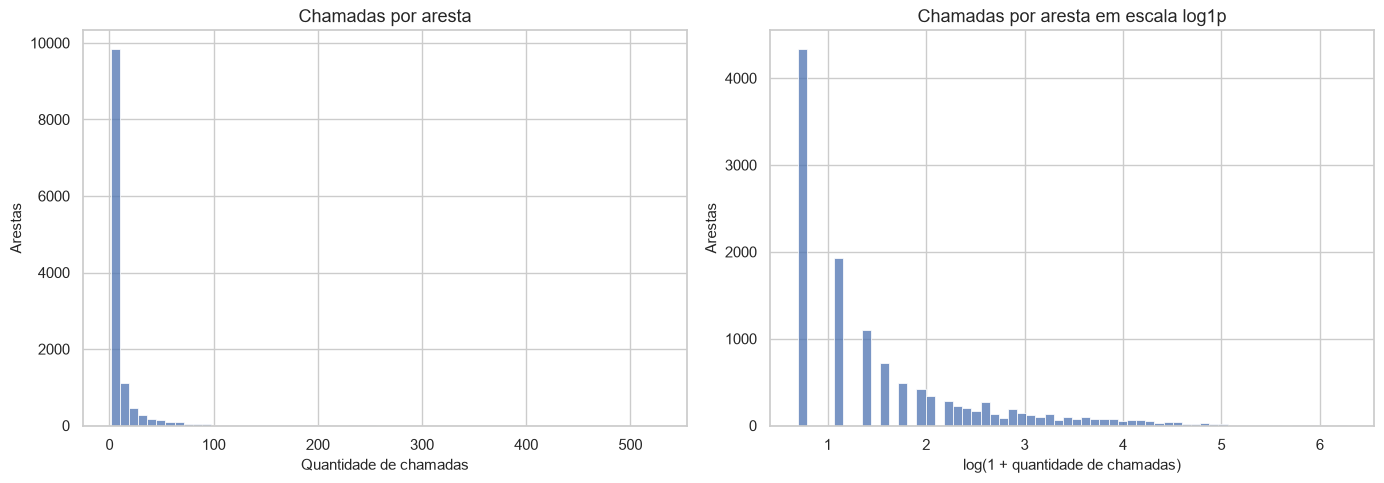

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data=edges, x='q_calls', bins=60, ax=axes[0])
axes[0].set_title('Chamadas por aresta')
axes[0].set_xlabel('Quantidade de chamadas')
axes[0].set_ylabel('Arestas')

sns.histplot(x=np.log1p(edges['q_calls']), bins=60, ax=axes[1], log_scale=(False, False))
axes[1].set_title('Chamadas por aresta em escala log1p')
axes[1].set_xlabel('log(1 + quantidade de chamadas)')
axes[1].set_ylabel('Arestas')

plt.tight_layout()
plt.show()

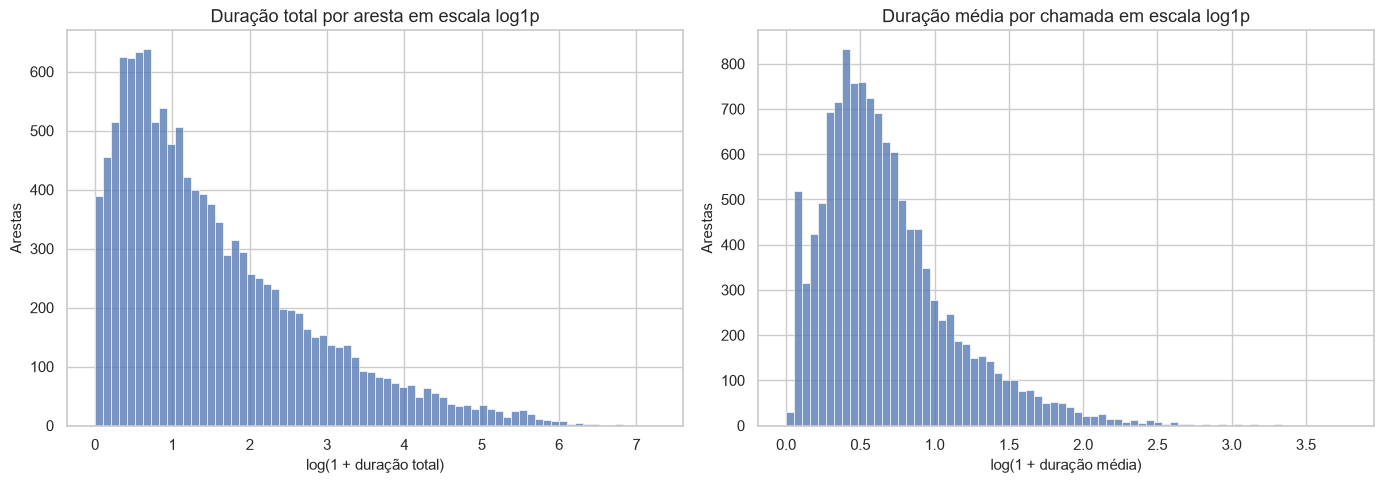

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(x=np.log1p(edges['calls_duration_total']), bins=70, ax=axes[0])
axes[0].set_title('Duração total por aresta em escala log1p')
axes[0].set_xlabel('log(1 + duração total)')
axes[0].set_ylabel('Arestas')

sns.histplot(x=np.log1p(edges['avg_duration_per_call']), bins=70, ax=axes[1])
axes[1].set_title('Duração média por chamada em escala log1p')
axes[1].set_xlabel('log(1 + duração média)')
axes[1].set_ylabel('Arestas')

plt.tight_layout()
plt.show()

## Distância residencial das arestas

Esta parte olha somente para a distância que já veio no parquet. A ideia é verificar se as arestas se concentram em distâncias curtas ou se existem muitos pares distantes.

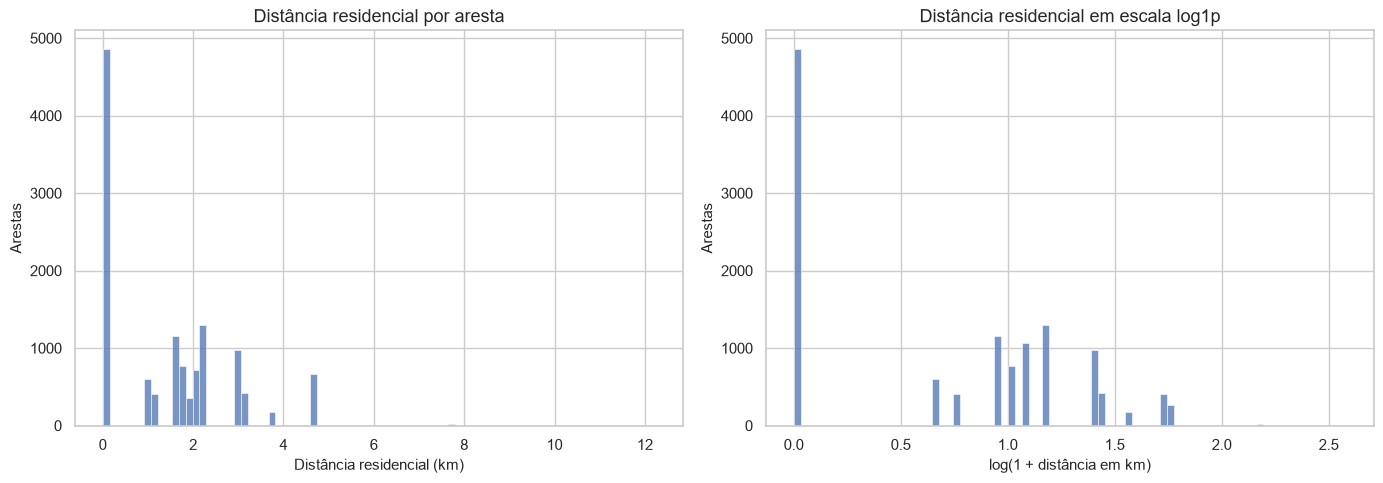

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data=edges, x='residence_distance_km', bins=80, ax=axes[0])
axes[0].set_title('Distância residencial por aresta')
axes[0].set_xlabel('Distância residencial (km)')
axes[0].set_ylabel('Arestas')

sns.histplot(x=np.log1p(edges['residence_distance_km']), bins=80, ax=axes[1])
axes[1].set_title('Distância residencial em escala log1p')
axes[1].set_xlabel('log(1 + distância em km)')
axes[1].set_ylabel('Arestas')

plt.tight_layout()
plt.show()

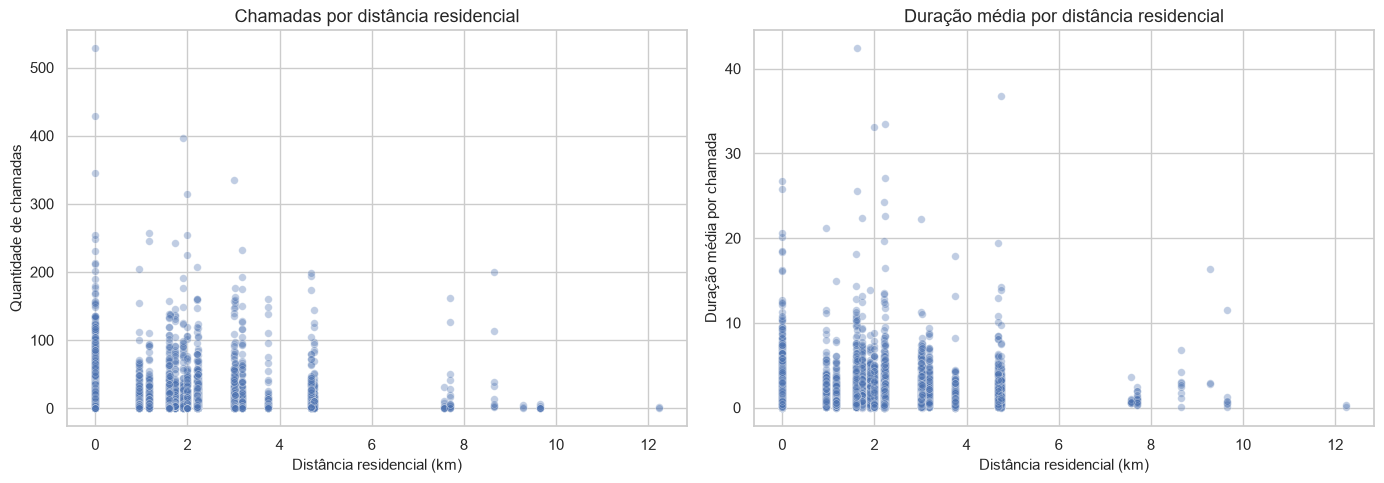

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(data=edges, x='residence_distance_km', y='q_calls', alpha=0.35, s=30, ax=axes[0])
axes[0].set_title('Chamadas por distância residencial')
axes[0].set_xlabel('Distância residencial (km)')
axes[0].set_ylabel('Quantidade de chamadas')

sns.scatterplot(data=edges, x='residence_distance_km', y='avg_duration_per_call', alpha=0.35, s=30, ax=axes[1])
axes[1].set_title('Duração média por distância residencial')
axes[1].set_xlabel('Distância residencial (km)')
axes[1].set_ylabel('Duração média por chamada')

plt.tight_layout()
plt.show()

In [25]:
edges['residence_distance_km'].describe(percentiles=[.01, .05, .25, .5, .75, .9, .95, .99])

count    12432.000000
mean         1.423080
std          1.435048
min          0.000000
1%           0.000000
5%           0.000000
25%          0.000000
50%          1.592705
75%          2.203147
90%          3.187210
95%          4.675603
99%          4.736802
max         12.231602
Name: residence_distance_km, dtype: float64

In [26]:
bins_distancia = [-np.inf, 1, 3, 5, 7, 9, 11, np.inf]
labels_distancia = ['<=1', '1-3', '3-5', '5-7', '7-9', '9-11',  '>11']

edges['faixa_distancia_km'] = pd.cut(
    edges['residence_distance_km'],
    bins=bins_distancia,
    labels=labels_distancia,
)

resumo_distancia = edges.groupby('faixa_distancia_km', observed=False).agg(
    arestas=('id_receiver', 'size'),
    chamadas=('q_calls', 'sum'),
    duracao_total=('calls_duration_total', 'sum'),
    chamadas_mediana=('q_calls', 'median'),
    duracao_media_chamada=('avg_duration_per_call', 'mean'),
).reset_index()
resumo_distancia['pct_arestas'] = resumo_distancia['arestas'] / resumo_distancia['arestas'].sum()
resumo_distancia['pct_chamadas'] = resumo_distancia['chamadas'] / resumo_distancia['chamadas'].sum()
resumo_distancia

,faixa_distancia_km,arestas,chamadas,duracao_total,chamadas_mediana,duracao_media_chamada,pct_arestas,pct_chamadas
0,<=1,5457,58729,70068.55,3.0,1.101021,0.438948,0.502150
1,1-3,4682,37072,59199.11,2.0,1.351485,0.376609,0.316977
2,3-5,2244,20175,35442.63,2.0,1.422716,0.180502,0.172502
3,5-7,0,0,0.00,NaN,NaN,0.000000,0.000000
4,7-9,37,954,1721.84,5.0,1.444240,0.002976,0.008157
5,9-11,10,22,122.53,1.0,3.730733,0.000804,0.000188
6,>11,2,3,0.40,1.5,0.162500,0.000161,0.000026


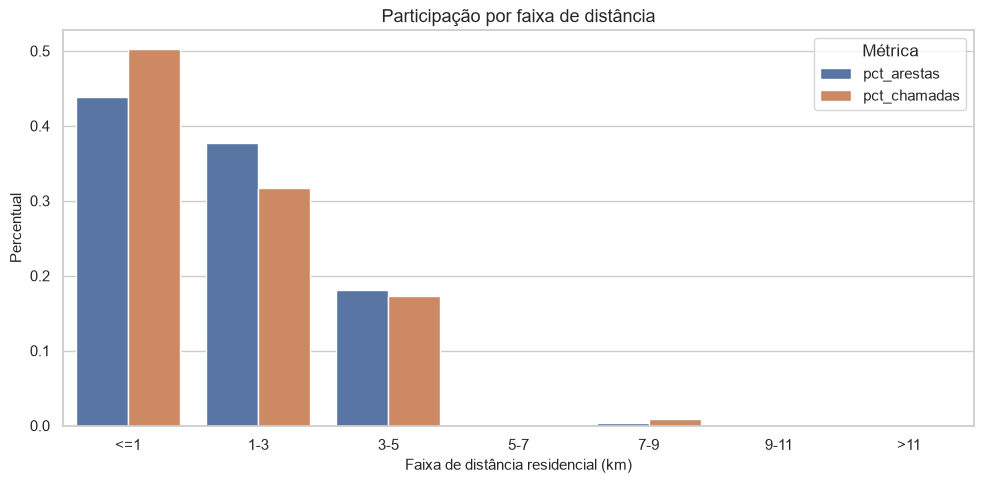

In [27]:
dist_plot = resumo_distancia.melt(
    id_vars='faixa_distancia_km',
    value_vars=['pct_arestas', 'pct_chamadas'],
    var_name='metrica',
    value_name='percentual',
)

plt.figure(figsize=(10, 5))
sns.barplot(data=dist_plot, x='faixa_distancia_km', y='percentual', hue='metrica')
plt.title('Participação por faixa de distância')
plt.xlabel('Faixa de distância residencial (km)')
plt.ylabel('Percentual')
plt.legend(title='Métrica')
plt.tight_layout()
plt.show()

## CCDF das chamadas por aresta

A CCDF mostra a proporção de arestas que têm pelo menos `x` chamadas. Ela é útil para enxergar a cauda da distribuição: poucos pares podem concentrar muitas chamadas, mesmo que a maioria dos pares tenha baixo volume.

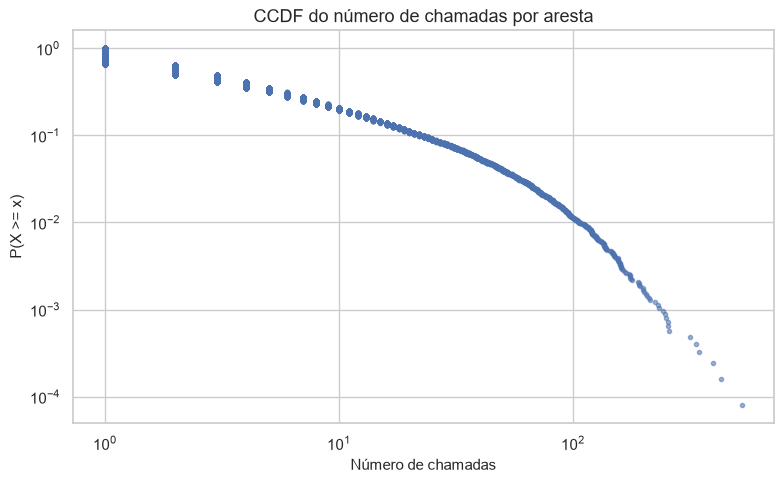

In [28]:
x = np.sort(edges['q_calls'].to_numpy())
y = 1.0 - np.arange(len(x)) / len(x)

plt.figure(figsize=(8, 5))
plt.plot(x, y, marker='.', linestyle='none', alpha=0.55)
plt.xscale('log')
plt.yscale('log')
plt.title('CCDF do número de chamadas por aresta')
plt.xlabel('Número de chamadas')
plt.ylabel('P(X >= x)')
plt.tight_layout()
plt.show()

## Pares emissor-receptor mais fortes

Esta é uma análise adicional simples: listar os pares com mais chamadas. Ela ajuda a verificar se existem relações muito intensas que podem influenciar médias e totais.

In [29]:
top_arestas = edges.sort_values('q_calls', ascending=False)
top_arestas.head(15)

,id_emisor,id_receiver,q_calls,residence_distance_km,calls_duration_total,avg_duration_per_call,faixa_distancia_km
10827,645254314639EDACA0DFCD37DCF6A2DD,17231B0968F170A835125CD6858E51A6,528,0.000000,864.64,1.637576,<=1
3355,1A1C2B664417B00DEF20104017E778BD,47A1310E83C6871424E6106584B5724A,429,0.000000,417.02,0.972075,<=1
5543,36FE36ED18B50C18B29D1A16275E64CF,1ED55B910C1FAB3E4D100743B7E735E8,397,1.909331,171.71,0.432519,1-3
5294,47A1310E83C6871424E6106584B5724A,1A1C2B664417B00DEF20104017E778BD,345,0.000000,384.15,1.113478,<=1
5857,8DE7ECCB2BD455F7883092DD0567D43B,5167F587A593E0737E8264F7E04698EB,335,3.008661,259.93,0.775910,3-5
4101,127BC2BA57366C0E58F1DC75427ED796,201CDBAE6784AC1D150EE746E8871351,315,1.996042,561.42,1.782286,1-3
948,CC2B4220FBE1D1EAE5874F64683D37AC,A6AE1DF871C578027801417C91B59ADA,257,1.160592,410.64,1.597821,1-3
4836,913A7D7725A8EA78348BF3D1CAAD9D5F,D0B17CC35185EC4064D818BEBA788D29,254,1.996042,141.76,0.558110,1-3
7914,986A9DCE796BBE832631B8B8C3705EF6,2BC48CAFBFF33D6982BFA78EE7F4FAEC,254,0.000000,452.73,1.782402,<=1
6862,17231B0968F170A835125CD6858E51A6,645254314639EDACA0DFCD37DCF6A2DD,249,0.000000,156.69,0.629277,<=1


## Concentração de contatos por emissor

Esta análise mede quanto cada emissor depende do seu principal receptor. O `share_top_receptor` é a proporção das chamadas do emissor que foram para o receptor mais chamado.

Valores perto de 1 indicam comunicação muito concentrada. Valores menores indicam chamadas mais distribuídas entre diferentes contatos.

In [30]:
concentracao = edges.groupby('id_emisor').agg(
    chamadas_total=('q_calls', 'sum'),
    receptores=('id_receiver', 'nunique'),
    maior_volume_receptor=('q_calls', 'max'),
).reset_index()
concentracao['share_top_receptor'] = concentracao['maior_volume_receptor'] / concentracao['chamadas_total']
concentracao['chamadas_por_receptor'] = concentracao['chamadas_total'] / concentracao['receptores']

concentracao.sort_values(['share_top_receptor', 'chamadas_total'], ascending=[False, False]).head(15)

,id_emisor,chamadas_total,receptores,maior_volume_receptor,share_top_receptor,chamadas_por_receptor
1925,A6AE1DF871C578027801417C91B59ADA,246,1,246,1.0,246.0
1702,952B1011CF6323AD86BD8063516BF73E,201,1,201,1.0,201.0
2201,BE5EA69D03B99BAFC8E7B043D8594450,176,1,176,1.0,176.0
2568,DE134714040F84618425F7C55D4EFF9D,175,1,175,1.0,175.0
2630,E37415FECDF84BBB69B65016768829F8,164,1,164,1.0,164.0
418,2277587CC10AA4EA7B98FC90A8E4F380,158,1,158,1.0,158.0
2488,D820BFA572F5CDE6019210745CF45246,156,1,156,1.0,156.0
2926,FC557420B3327899B0B8A0868D138A06,155,1,155,1.0,155.0
1,0013DE3AD6D78AA642B81409E429539B,147,1,147,1.0,147.0
2154,B9E8AF866E3138705C21E38EF8906AE7,146,1,146,1.0,146.0


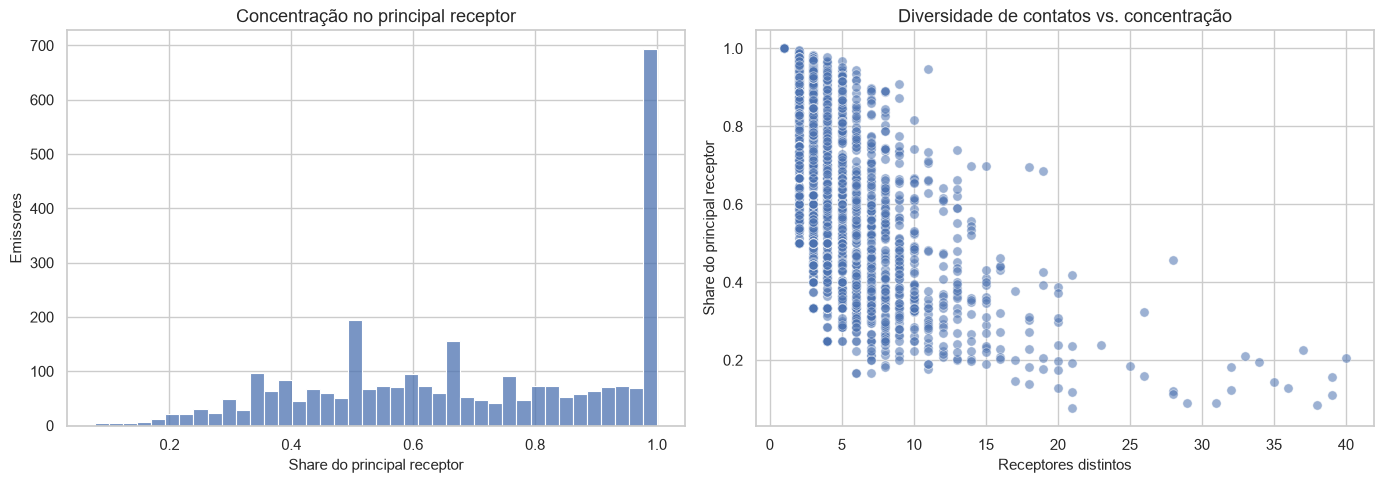

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data=concentracao, x='share_top_receptor', bins=40, ax=axes[0])
axes[0].set_title('Concentração no principal receptor')
axes[0].set_xlabel('Share do principal receptor')
axes[0].set_ylabel('Emissores')

sns.scatterplot(data=concentracao, x='receptores', y='share_top_receptor', alpha=0.55, s=45, ax=axes[1])
axes[1].set_title('Diversidade de contatos vs. concentração')
axes[1].set_xlabel('Receptores distintos')
axes[1].set_ylabel('Share do principal receptor')

plt.tight_layout()
plt.show()

## Classificação simples de emissores

Para facilitar a leitura, criamos faixas simples de atividade com base no número total de chamadas. Esta classificação não é um modelo; é apenas um resumo exploratório para entender a composição da base.

In [32]:
bins_chamadas = [-np.inf, 1, 5, 10, 25, 50, 100, np.inf]
labels_chamadas = ['1', '2-5', '6-10', '11-25', '26-50', '51-100', '>100']

df['faixa_total_chamadas'] = pd.cut(
    df['total_calls_make'],
    bins=bins_chamadas,
    labels=labels_chamadas,
)

faixa_emissores = df.groupby('faixa_total_chamadas', observed=False).agg(
    emissores=('id_emisor', 'size'),
    chamadas=('total_calls_make', 'sum'),
    receptores_mediana=('unique_receivers', 'median'),
).reset_index()
faixa_emissores['pct_emissores'] = faixa_emissores['emissores'] / faixa_emissores['emissores'].sum()
faixa_emissores['pct_chamadas'] = faixa_emissores['chamadas'] / faixa_emissores['chamadas'].sum()
faixa_emissores

,faixa_total_chamadas,emissores,chamadas,receptores_mediana,pct_emissores,pct_chamadas
0,1,230,230,1.0,0.077493,0.001967
1,2-5,508,1631,2.0,0.171159,0.013946
2,6-10,345,2678,3.0,0.116240,0.022898
3,11-25,557,9539,3.0,0.187668,0.081561
4,26-50,568,20942,4.0,0.191375,0.179060
5,51-100,462,32854,5.0,0.155660,0.280911
6,>100,298,49081,6.0,0.100404,0.419657


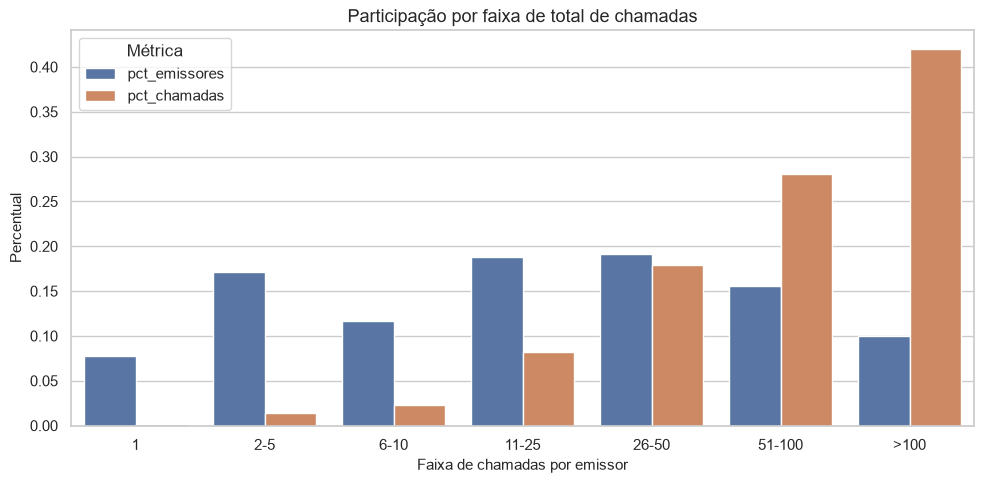

In [33]:
faixa_plot = faixa_emissores.melt(
    id_vars='faixa_total_chamadas',
    value_vars=['pct_emissores', 'pct_chamadas'],
    var_name='metrica',
    value_name='percentual',
)

plt.figure(figsize=(10, 5))
sns.barplot(data=faixa_plot, x='faixa_total_chamadas', y='percentual', hue='metrica')
plt.title('Participação por faixa de total de chamadas')
plt.xlabel('Faixa de chamadas por emissor')
plt.ylabel('Percentual')
plt.legend(title='Métrica')
plt.tight_layout()
plt.show()

## Leituras iniciais

- A base está agregada por emissor; por isso, a primeira parte da EDA olha para comportamento individual dos emissores.
- A expansão para arestas é essencial para analisar pares emissor-receptor de forma simples.
- O total de chamadas e a quantidade de chamadas por aresta parecem exigir leitura por mediana, percentis, Pareto e CCDF, porque poucos casos podem concentrar muito volume.
- A distância residencial permite verificar se a comunicação se concentra em pares próximos ou se há volume relevante em pares mais distantes.
- `chamadas_por_receptor` e `share_top_receptor` ajudam a separar emissores com comunicação distribuída daqueles com comunicação concentrada.
- Esta versão usa apenas informações presentes no parquet; nenhum cruzamento externo é feito.

# Exportação da tabela de emissores - receptores

In [34]:
edges.drop(columns=['faixa_distancia_km'], inplace=True)
out_path = DATA_DIR / 'edges.csv'
edges.to_csv(out_path, index=False)
print(f'Saved edges ({len(edges):,} rows) to {out_path}')

Saved edges (12,432 rows) to dados\edges.csv


In [35]:
edges.head()

,id_emisor,id_receiver,q_calls,residence_distance_km,calls_duration_total,avg_duration_per_call
0,6A25BB13E0EB57AF0BC1B12E09066090,09733364070D428DB7DB059EB964AEEA,3,1.624481,8.47,2.823333
1,A1F433373241547B7E7D0E4E63A8574F,EAFB8A6F8D9AD7E91529F6EF7F15BF2B,27,1.624481,19.59,0.725556
2,C0EE955E574B587D037F1DC493ADDEC4,54AAE028CCC31C4B800CB1E7E9799253,1,3.008661,1.43,1.430000
3,66406B8907461FBB978468BE0D0E22F1,033183C2EE18E03EFDF1083D53EE92B5,3,1.592705,29.29,9.763333
4,EB4EF78A3B0BAAD118885F2B93881B5F,3F895921B209C4161B721382802BD3BC,21,0.000000,18.19,0.866190


In [36]:
edges.info()

<class 'pandas.DataFrame'>
RangeIndex: 12432 entries, 0 to 12431
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id_emisor              12432 non-null  str    
 1   id_receiver            12432 non-null  str    
 2   q_calls                12432 non-null  int64  
 3   residence_distance_km  12432 non-null  float64
 4   calls_duration_total   12432 non-null  float64
 5   avg_duration_per_call  12432 non-null  float64
dtypes: float64(3), int64(1), str(2)
memory usage: 1.3 MB


# Agregação das informações de localização

Primeiro, devemos entender o que os dados da tabela `residencias.csv` significam:

- `ID`: é o mesmo identificador utilizado na tabela anterior. Cada pessoa possui um ID único.
- `residence_geometry`: representa a localização geográfica da residência no formato `Well-Known Binary (WKB)`. Posteriormente, será necessário converter esses dados para coordenadas utilizáveis, como latitude e longitude.
- `residence_city`: cidade de residência do usuário.
- `residence_quintile_state`: indica o quintil socioeconômico do usuário dentro do estado.
- `residence_quintile_nation`: indica o quintil socioeconômico do usuário em relação ao país inteiro.

Os quintis dividem a população em cinco grupos socioeconômicos:

| Quintil | Significado            |
|----------|-------------------------|
| q1       | 20% mais pobres         |
| q2       | Faixa intermediária baixa |
| q3       | Faixa intermediária     |
| q4       | Faixa intermediária alta |
| q5       | 20% mais ricos          |

Essas informações permitem relacionar características socioeconômicas e geográficas com os padrões de comunicação observados na rede telefônica, possibilitando análises envolvendo:
- desigualdade social;
- distribuição espacial das conexões;
- intensidade de comunicação por região;
- comportamento de diferentes grupos socioeconômicos;
- formação de comunidades e hubs na rede.

A ideia é agregar os dados da localização do emissor e receptor, e os quintis do emissor e receptor no dataframe `edges.csv`, para uma futura análise do sistema complexo que montaremos

In [37]:
residencias = pd.read_csv(RESIDENCIAS_PATH)

In [38]:
residencias.head()

,ID,residence_geometry,residence_city,residence_quintile_state,residence_quintile_nation
0,0A7BF148110B6D5AE29939017AEB843A,b'\x01\x01\x00\x00\x00Cn\x86\x1b\xf0eG\xc0D\xc0!T\xa9\xa97\xc0',São Paulo,q1,q1
1,0FBC0A930414D2ED92B6F4B8661BB997,b'\x01\x01\x00\x00\x00Cn\x86\x1b\xf0eG\xc0D\xc0!T\xa9\xa97\xc0',São Paulo,q1,q1
2,0BA404BCA3069A8C9FA6ABE70225A1C8,b'\x01\x01\x00\x00\x00Cn\x86\x1b\xf0eG\xc0D\xc0!T\xa9\xa97\xc0',São Paulo,q1,q1
3,133947C1230823B09FA68416DED5E090,b'\x01\x01\x00\x00\x00Cn\x86\x1b\xf0eG\xc0D\xc0!T\xa9\xa97\xc0',São Paulo,q1,q1
4,0FADED95A81CAC14BD136CAAF597E425,b'\x01\x01\x00\x00\x00Cn\x86\x1b\xf0eG\xc0D\xc0!T\xa9\xa97\xc0',São Paulo,q1,q1


In [39]:
# Selecionamos da base de residencias apenas as colunas de localizacao e quintil.
# A juncao completa em `edges` nao e feita aqui: a tabela final por antena e
# construida adiante, a partir dos IDs com residencia conhecida.
res = residencias[[
    "ID",
    "residence_geometry",
    "residence_city",
    "residence_quintile_state",
    "residence_quintile_nation",
]].copy()

# Padroniza os IDs como string para casar com `edges`.
edges["id_emisor"] = edges["id_emisor"].astype(str).str.strip()
edges["id_receiver"] = edges["id_receiver"].astype(str).str.strip()
res["ID"] = res["ID"].astype(str).str.strip()

res.head()

,ID,residence_geometry,residence_city,residence_quintile_state,residence_quintile_nation
0,0A7BF148110B6D5AE29939017AEB843A,b'\x01\x01\x00\x00\x00Cn\x86\x1b\xf0eG\xc0D\xc0!T\xa9\xa97\xc0',São Paulo,q1,q1
1,0FBC0A930414D2ED92B6F4B8661BB997,b'\x01\x01\x00\x00\x00Cn\x86\x1b\xf0eG\xc0D\xc0!T\xa9\xa97\xc0',São Paulo,q1,q1
2,0BA404BCA3069A8C9FA6ABE70225A1C8,b'\x01\x01\x00\x00\x00Cn\x86\x1b\xf0eG\xc0D\xc0!T\xa9\xa97\xc0',São Paulo,q1,q1
3,133947C1230823B09FA68416DED5E090,b'\x01\x01\x00\x00\x00Cn\x86\x1b\xf0eG\xc0D\xc0!T\xa9\xa97\xc0',São Paulo,q1,q1
4,0FADED95A81CAC14BD136CAAF597E425,b'\x01\x01\x00\x00\x00Cn\x86\x1b\xf0eG\xc0D\xc0!T\xa9\xa97\xc0',São Paulo,q1,q1


Parece que alguns emissores e rececptores não existem, vamos verificar isso

## Verificação dos nós sem informações de localização

In [40]:
# 1. Quantos emissores não existem em residencias?
ids_res = set(res["ID"])

faltando_emissor = ~edges["id_emisor"].isin(ids_res)

print("Emissores sem residência:", faltando_emissor.sum())
print("Total de emissores:", len(edges))
print("Percentual:", 100 * faltando_emissor.mean(), "%")

Emissores sem residência: 0
Total de emissores: 12432
Percentual: 0.0 %


In [41]:
# 2. Quantos receptores não existem?
faltando_receptor = ~edges["id_receiver"].isin(ids_res)

print("Receptores sem residência:", faltando_receptor.sum())
print("Total de receptores:", len(edges))
print("Percentual:", 100 * faltando_receptor.mean(), "%")

Receptores sem residência: 0
Total de receptores: 12432
Percentual: 0.0 %


In [42]:
# 3. Quais IDs estão faltando?
ids_emissor_faltando = set(
    edges.loc[faltando_emissor, "id_emisor"]
)

ids_receptor_faltando = set(
    edges.loc[faltando_receptor, "id_receiver"]
)

print("Emissores únicos faltando:", len(ids_emissor_faltando))
print("Receptores únicos faltando:", len(ids_receptor_faltando))

Emissores únicos faltando: 0
Receptores únicos faltando: 0


In [43]:
# Mostrar alguns exemplos:
list(ids_emissor_faltando)[:20]

[]

In [44]:
# 5. Verificar se o problema é tipo de dado
print(edges["id_emisor"].dtype)
print(res["ID"].dtype)

str
str


In [45]:
# IDs presentes na rede mas ausentes em residencias.csv
ids_edges = set(edges["id_emisor"]) | set(edges["id_receiver"])
ids_res = set(res["ID"])
ids_sem_res = ids_edges - ids_res

print(f"Nos sem residencia: {len(ids_sem_res)}")

Nos sem residencia: 0


In [46]:
grau_emissor = edges["id_emisor"].value_counts()
grau_receptor = edges["id_receiver"].value_counts()

grau_total = grau_emissor.add(
    grau_receptor,
    fill_value=0
)

In [47]:
graus_faltantes = grau_total.reindex(list(ids_sem_res))

print(graus_faltantes.describe())

count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: count, dtype: float64


In [48]:
graus_faltantes.sort_values(
    ascending=False
).head(20)

Series([], Name: count, dtype: float64)

In [49]:
grau_total.describe()

count    3112.000000
mean        7.989717
std         8.129332
min         1.000000
25%         3.000000
50%         6.000000
75%        10.000000
max        78.000000
Name: count, dtype: float64

### Conclusão sobre os nós sem localização

Cerca de **7,8% dos nós** da rede não têm residência cadastrada em `residencias.csv`. Esses nós têm
grau baixo (mediana 3), ou seja, são usuários periféricos, e não hubs. Por isso eles são removidos
ao construir a tabela final por antena (a seguir): mantemos apenas arestas em que emissor **e**
receptor têm residência conhecida, garantindo que toda a rede espacial tenha coordenadas.

## Construção das tabelas de antena e usuário

A partir dos IDs com residência conhecida, criamos: (1) `edges_antenna`, com as arestas filtradas e
o identificador de antena de cada extremo; e (2) `antennas`, a tabela de antenas residenciais
distintas com cidade e quintis. Essas duas tabelas, restritas a Campinas, alimentam o notebook de
rede complexa.

In [50]:
import pandas as pd

from pathlib import Path



if "DATA_DIR" not in globals():

    DATA_DIR = Path("./dados")



if "edges" not in globals():

    edges = pd.read_csv(DATA_DIR / "edges.csv")



if "res" not in globals():

    residencias = pd.read_csv(DATA_DIR / "residencias.csv")

    res = residencias[[

        "ID",

        "residence_geometry",

        "residence_city",

        "residence_quintile_state",

        "residence_quintile_nation",

    ]].copy()



edges["id_emisor"] = edges["id_emisor"].astype(str).str.strip()

edges["id_receiver"] = edges["id_receiver"].astype(str).str.strip()

res["ID"] = res["ID"].astype(str).str.strip()



ids_res = set(res["ID"])



edges_antenna = edges[

    edges["id_emisor"].isin(ids_res)

    & edges["id_receiver"].isin(ids_res)

].copy()

In [51]:
res_antenna_base = res[[

    "ID",

    "residence_geometry",

    "residence_city",

    "residence_quintile_state",

    "residence_quintile_nation",

]].copy()



# Cada geometria de residência representa uma antena.

antenna_key = (

    res_antenna_base["residence_geometry"]

    .astype("string")

    .fillna("<NA>")

)

res_antenna_base["antenna_id"] = pd.factorize(

    antenna_key,

    sort=True

)[0] + 1



antennas = (

    res_antenna_base[[

        "antenna_id",

        "residence_geometry",

        "residence_city",

        "residence_quintile_state",

        "residence_quintile_nation",

    ]]

    .drop_duplicates(subset=["antenna_id"])

    .sort_values("antenna_id")

    .reset_index(drop=True)

)



user_to_antenna = res_antenna_base.set_index("ID")["antenna_id"]



edges_antenna["emissor_antenna_id"] = (

    edges_antenna["id_emisor"]

    .map(user_to_antenna)

    .astype("Int64")

)



edges_antenna["receptor_antenna_id"] = (

    edges_antenna["id_receiver"]

    .map(user_to_antenna)

    .astype("Int64")

)

In [52]:
edges_antenna[["emissor_antenna_id", "receptor_antenna_id"]].isna().sum()

emissor_antenna_id     0
receptor_antenna_id    0
dtype: int64

In [53]:
print(edges_antenna.shape)

print(antennas.shape)



edges_antenna.head()

(12432, 8)
(8530, 5)


,id_emisor,id_receiver,q_calls,residence_distance_km,calls_duration_total,avg_duration_per_call,emissor_antenna_id,receptor_antenna_id
0,6A25BB13E0EB57AF0BC1B12E09066090,09733364070D428DB7DB059EB964AEEA,3,1.624481,8.47,2.823333,2098,2960
1,A1F433373241547B7E7D0E4E63A8574F,EAFB8A6F8D9AD7E91529F6EF7F15BF2B,27,1.624481,19.59,0.725556,2098,2960
2,C0EE955E574B587D037F1DC493ADDEC4,54AAE028CCC31C4B800CB1E7E9799253,1,3.008661,1.43,1.430000,2960,6339
3,66406B8907461FBB978468BE0D0E22F1,033183C2EE18E03EFDF1083D53EE92B5,3,1.592705,29.29,9.763333,6300,6874
4,EB4EF78A3B0BAAD118885F2B93881B5F,3F895921B209C4161B721382802BD3BC,21,0.000000,18.19,0.866190,5582,5582


In [54]:
antennas.head()

,antenna_id,residence_geometry,residence_city,residence_quintile_state,residence_quintile_nation
0,1,"b""\x01\x01\x00\x00\x00 $\x0b\x98\xc0\x99I\xc0\x81!\xab[='=\xc0""",Caxias do Sul,q5,q5
1,2,"b""\x01\x01\x00\x00\x00!\xb0rh\x91\xddA\xc0}'f\xbd\x18:#\xc0""",Maceió,q5,q5
2,3,"b""\x01\x01\x00\x00\x00#J{\x83/\x98I\xc0\x16Mg'\x83\x1b=\xc0""",Caxias do Sul,q2,q3
3,4,"b""\x01\x01\x00\x00\x00#\x84G\x1bG\x90A\xc0|'f\xbd\x18\xea\x17\xc0""",Natal,q4,q3
4,5,"b""\x01\x01\x00\x00\x00#\xee\xb1\xf4\xa1'H\xc0\x85\xcek\xec\x12\xd5\xf5\xbf""",Belém,q1,q1


In [55]:
antennas = antennas[antennas['residence_city'] == CITY_NAME]

In [56]:
antennas.shape

(7, 5)

In [57]:
edges_out_path = DATA_DIR / 'edges_antenna.parquet'

antennas_out_path = DATA_DIR / 'antennas.parquet'



edges_antenna.to_parquet(

    edges_out_path,

    index=True

)



antennas.to_parquet(

    antennas_out_path,

    index=False

)



print(f'Arestas com antenna_id salvas em: {edges_out_path}')

print(f'Tabela de antenas salva em: {antennas_out_path}')

Arestas com antenna_id salvas em: dados\edges_antenna.parquet
Tabela de antenas salva em: dados\antennas.parquet
